In [1]:
'''
    手写阿拉伯数字
'''
import tensorflow as tf
#加载数据,导入MNIST手写阿拉伯数字数据集
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

#特征缩放(0,1)区间
x_train,x_test=x_train/255.0,x_test/255.0
#建立模型
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)), #数据预处理层,将输入的多为数据展评成一维的向量。 输入层不需要单独审评
    tf.keras.layers.Dense(128,activation='relu'), #全连接层,具有128个神经元，激活函数为relu
    tf.keras.layers.Dropout(0.2), #随机丢弃20%的神经元,防止过拟合
    tf.keras.layers.Dense(10,activation='softmax') #输出层,10个神经元,激活函数为softmax
])

#设定模型参数,优化器、损失函数、效果衡量指标
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#模型训练
model.fit(x_train,y_train,epochs=5,validation_split=0.2)

#模型评估
model.evaluate(x_test,y_test)

E:\develop\anaconda3\envs\d2l_tensorflow\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8424 - loss: 0.5367 - val_accuracy: 0.9564 - val_loss: 0.1520
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9510 - loss: 0.1686 - val_accuracy: 0.9681 - val_loss: 0.1097
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9648 - loss: 0.1178 - val_accuracy: 0.9692 - val_loss: 0.1011
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9697 - loss: 0.0965 - val_accuracy: 0.9728 - val_loss: 0.0862
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9739 - loss: 0.0797 - val_accuracy: 0.9755 - val_loss: 0.0896
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9703 - loss: 0.0980


[0.08389285951852798, 0.9731000065803528]

In [2]:
'''
    机器学习流程十大步骤:
'''
#1.MNIST手写阿拉伯数字数据集
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()
#训练/测试数据的X/y维度
# print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

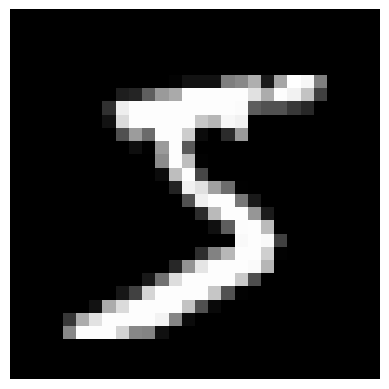

In [3]:
#2.EDA,对数据集进行探索与分析,首先观察训练数据的目标值(y),即影像的真实结果
##训练数据集前10张图片的数字
# print(y_train[:10])
##打印第一个训练数据的像素
print(x_train[0])

##可视化图片中手写的数字
###将非0的数字转为1,显示第一张图片
data = x_train[0].copy()
data[data > 0] = 1

###将转换后的二维内容展示出来,隐约是5
text_image = []
for i in range(data.shape[0]):
    text_image.append(''.join(str(data[i])))

print('\n'.join(text_image))

#显示第一个训练数据图像
import matplotlib.pyplot as plt

#第一批数据
X2 = x_train[0,:,:]
#绘制点阵图 cmap='gray'表示灰度图
plt.imshow(X2.reshape(28,28),cmap='gray')

#隐藏刻度
plt.axis('off')

#显示图形
plt.show()

In [4]:
#3.进行特征工程,将特征缩放到(0,1)区间,特征缩放可以提高模型准确度,并且可以加快收敛速度。特征缩量采用正态化公式
#正态化公式:X_norm = (X - X_min)/(X_max - X_min)
#颜色范围0-255,所以缩放公式为:X_norm = X/255
#颜色0为白色,与RGB颜色不同,(0,0,0)为黑色
x_train_norm,x_test_norm=x_train/255.0,x_test/255.0
print(x_train_norm[0])

# 4,数据分割为训练数据和测试数据。加载MNIST数据集时,数据已经Been split into train and test sets.
# 5,建立模型结构,keras提供两类模型,包括顺序模型(Sequential Model)及Functional API模型。Functional API模型可以建立更复杂的模型,如多输入模型、多输出模型。
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)), #数据预处理层,将输入的多为数据展评成一维的向量。 输入层不需要单独指定
    tf.keras.layers.Dense(128,activation='relu'), #完全连接层,具有128个神经元，激活函数为relu。128个神经元即128条回归线,每一条回归线有784个特征,输出通常定为4的倍数。
    tf.keras.layers.Dropout(0.2), #随机丢弃20%的神经元,防止过拟合。通常会在每一层Dense之后都是加一个Dropout层
    tf.keras.layers.Dense(10,activation='softmax') #输出层,也是一个完全连接层,10个神经元,激活函数为softmax。输出层通常定义为10个神经元,因为手写阿拉伯数字有10个数字,0-9。
])
# 6,模型编译,模型编译时,需要指定优化器、损失函数、效果衡量指标。优化器采用adam,损失函数采用sparse_categorical_crossentropy,效果衡量指标采用accuracy。
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',#损失函数为交叉熵,而非MSE
              metrics=['accuracy'])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8418 - loss: 0.5358 - val_accuracy: 0.9532 - val_loss: 0.1630
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9487 - loss: 0.1754 - val_accuracy: 0.9631 - val_loss: 0.1242
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9619 - loss: 0.1238 - val_accuracy: 0.9682 - val_loss: 0.1059
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9705 - loss: 0.0967 - val_accuracy: 0.9727 - val_loss: 0.0910
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9752 - loss: 0.0791 - val_accuracy: 0.9722 - val_loss: 0.0894


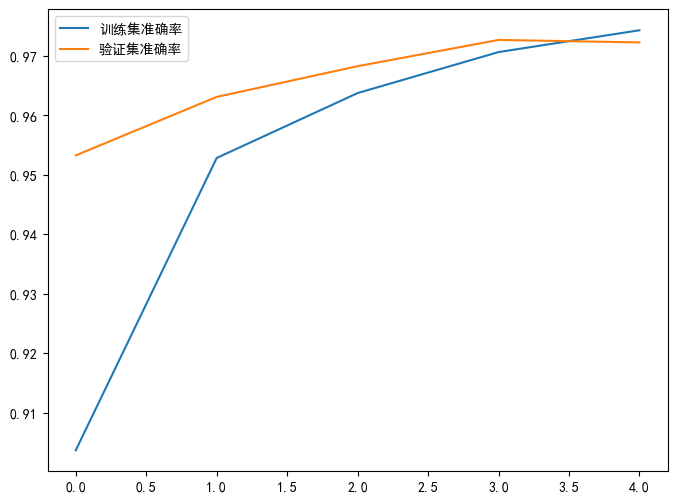

In [5]:
#7.步骤6: 结合训练数据及模型结构,进行模型训练
history = model.fit(x_train_norm,y_train,
                    epochs=5,#所有数据经过一次正向和反向传导,称之为一次执行周期。训练5个周期,即训练5个执行周期。
                    validation_split=0.2)
#对训练过程的准确绘图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'],label='训练集准确率')
plt.plot(history.history['val_accuracy'],label='验证集准确率')
plt.legend()

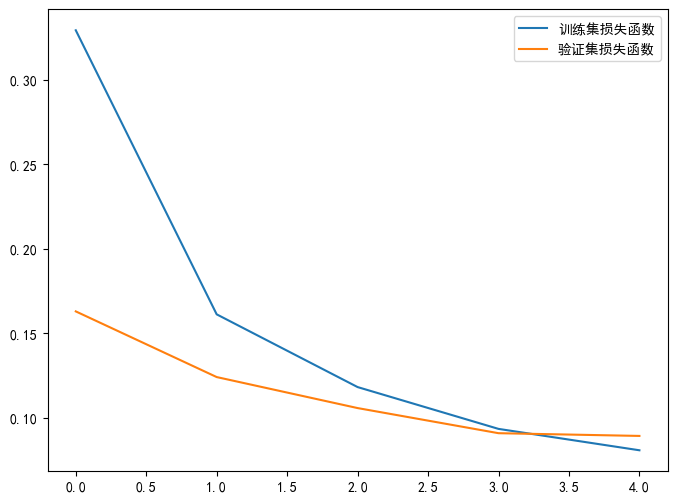

In [6]:
#训练过程中的损失函数图,如下图所示,随着执行周期次数的增加,损失越来越低,验证数据与训练数据的损失应趋于一致
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'],label='训练集损失函数')
plt.plot(history.history['val_loss'],label='验证集损失函数')
plt.legend()

In [11]:
# 步骤7: 评分(Score Model),使用evaluate()函数,输入测试数据,会计算出损失及准确率
score = model.evaluate(x_test_norm,y_test,verbose=0)
for i,x in enumerate(score):
    print(f'{model.metrics_names[i]}:{score[i]:.4f}')

#实际对比测试数据的前20个,使用predict()函数,输入测试数据,会返回一个10个元素的向量,表示每个数字的概率。
predictions = model.predict_classes(x_test_norm)

#比对实际结果与预测结果
print('actual    :',y_test[0:20])
print('prediction:',predictions[0:20])


loss:0.0777
compile_metrics:0.9757


AttributeError: 'Sequential' object has no attribute 'predict_classes'